In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45

from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
)

from logger import Logger

/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

In [3]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

N = 4
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)

def get_vstate(n_samples):
    model = nk.models.RBM(param_dtype=complex, alpha=1)
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains=n_samples)
    model = nk.models.RBM(
        alpha=1,
        param_dtype=complex,
        use_visible_bias=True,
        hidden_bias_init=nn.initializers.normal(1e-3),
        visible_bias_init=nn.initializers.normal(1e-3),
        kernel_init=nn.initializers.normal(1e-3),
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=100, sampler_seed=100
    )
    eps_params = vstate.parameters.copy()
    K = 3
    a = jnp.array([K,-K,-K,-K], dtype=eps_params['visible_bias'].dtype)
    eps_params["visible_bias"] = a
    vstate.parameters = eps_params.copy()
    
    # Thermalize
    for i in range(100):
        vstate.sample(n_samples=n_samples)
    return vstate


vstate = get_vstate(2**9)
print("Single peak state")
print(vstate.to_array())

Single peak state
[1.52298651e-08-6.97878473e-14j 6.14410703e-06-9.44823978e-12j
 6.14410969e-06-2.26546683e-11j 2.47870786e-03-3.06247552e-10j
 6.14411866e-06+8.78021087e-12j 2.47870923e-03-4.69131222e-09j
 2.47870593e-03+4.23646839e-09j 9.99987712e-01-1.09340804e-06j
 3.77511567e-11-6.95491367e-17j 1.52296523e-08+5.95727482e-14j
 1.52297706e-08-5.25615781e-14j 6.14407847e-06+1.73375354e-11j
 1.52297829e-08+1.75013155e-14j 6.14407788e-06+3.29850403e-12j
 6.14411477e-06-6.60347291e-12j 2.47871152e-03-2.89497919e-09j]


In [4]:
graph = nk.graph.Chain(N, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=1., J=-1.)
n_samples_list = [2**i for i in range(9,15)]

for i in range(N):
    string = ["I"]*N
    string[i] = "Z"
    if i==0:
        sigma_zs=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
    else:
        sigma_zs+=nk.operator.PauliStringsJax(hilbert, "".join(string), 1./N)
fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
)


def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_zs)
    return True

# Exact dynamics

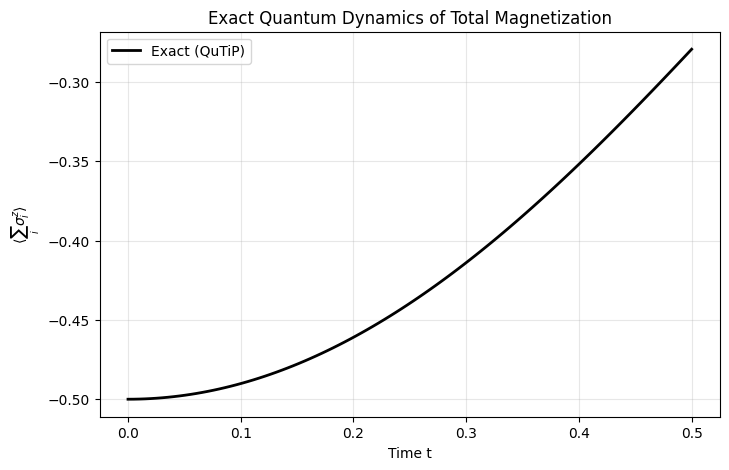

Initial magnetization: -0.499994
Final magnetization: -0.279265


In [5]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_dense()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
sigma_z_matrix = sigma_zs.to_dense() * N  # Multiply by N since sigma_zs is normalized by 1/N

# Convert to QuTiP
Z_total_qutip = qt.Qobj(sigma_z_matrix)

# Time evolution parameters
T = 0.5
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(Z_total_qutip, psi_t)
    magnetizations_exact.append(mag / 4)

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='Exact (QuTiP)')
plt.xlabel('Time t')
plt.ylabel(r'$\langle \sum_i \sigma^z_i \rangle$')
plt.title('Exact Quantum Dynamics of Total Magnetization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial magnetization: {np.real(magnetizations_exact[0]):.6f}")
print(f"Final magnetization: {np.real(magnetizations_exact[-1]):.6f}")

## Standard Dynamics

In [ ]:
from schmitt_tdvp import TDVPSchmitt

def fit(n_samples_tvmc):    
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"fixed_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook
    
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = []
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmitt(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
        **tvmc_kwargs,
    )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [7]:
for n_samples_tvmc in n_samples_list:
    fit(n_samples_tvmc)


Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...
Data exists, skipping...


Restored: True
Restored: True
Restored: True
Restored: True
Restored: True
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


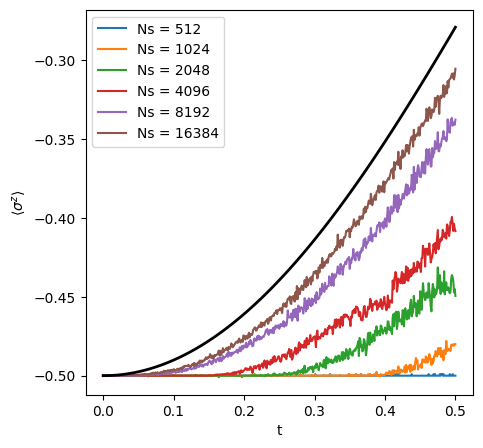

In [ ]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"fixed_{n_samples}"
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}")
   
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")
ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')


In [ ]:
from schmitt_tdvp_bridge import TDVPSchmittBridge

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 20)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    
    vstate = get_vstate(n_samples_tvmc)
    print(vstate.expect(sigma_zs))
    callbacks = [ ]
    callbacks.append(measure_sigma_z)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    integrator = RK45(1e-3, adaptive=False, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        q=0.2,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)



In [15]:
for n_samples_tvmc in n_samples_list:
    fit_bridge(n_samples_tvmc)

File not found
-5.00e-01+0.00e+00j ± nan [σ²=0.0e+00]


100%|██████████| 0.50/0.50 [00:40<00:00, 81.6s/it, n=500, Generator=0.005+0.347j ± 0.096 [σ²=4.7e+00]]   


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 40.930                                                                                                   │
│ ├── (1.3%) | MCState.expect : 0.514 s                                                                           │
│ ├── (15.5%) | MCState.sample : 6.335 s                                                                          │
│ │   └── (58.9%) | sampling n_discarded samples : 3.729 s                                                        │
│ ├── (5.7%) | QGTJacobian_DefaultConstructor : 2.328 s                                                           │
│ │   └── (40.5%) | jacobian : 0.942 s                                                                            │
│ └── (16.7%) | _impl : 6.850 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

100%|██████████| 0.50/0.50 [00:31<00:00, 62.6s/it, n=500, Generator=-0.007+0.349j ± 0.068 [σ²=4.7e+00]]  


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 31.355                                                                                                   │
│ ├── (1.2%) | MCState.expect : 0.378 s                                                                           │
│ ├── (16.7%) | MCState.sample : 5.223 s                                                                          │
│ │   └── (65.2%) | sampling n_discarded samples : 3.407 s                                                        │
│ ├── (5.9%) | QGTJacobian_DefaultConstructor : 1.856 s                                                           │
│ │   └── (42.9%) | jacobian : 0.796 s                                                                            │
│ └── (18.0%) | _impl : 5.656 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

...

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 32.527                                                                                                   │
│ ├── (1.3%) | MCState.expect : 0.437 s                                                                           │
│ ├── (19.5%) | MCState.sample : 6.345 s                                                                          │
│ │   └── (68.1%) | sampling n_discarded samples : 4.319 s                                                        │
│ ├── (6.2%) | QGTJacobian_DefaultConstructor : 2.026 s                                                           │
│ │   └── (48.2%) | jacobian : 0.978 s                                                                            │
│ └── (20.2%) | _impl : 6.581 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

100%|██████████| 0.50/0.50 [00:46<00:00, 93.1s/it, n=500, Generator=0.012+0.385j ± 0.024 [σ²=4.7e+00]]      


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 46.634                                                                                                   │
│ ├── (1.2%) | MCState.expect : 0.545 s                                                                           │
│ ├── (40.6%) | MCState.sample : 18.938 s                                                                         │
│ │   └── (78.8%) | sampling n_discarded samples : 14.923 s                                                       │
│ ├── (8.2%) | QGTJacobian_DefaultConstructor : 3.832 s                                                           │
│ │   └── (73.6%) | jacobian : 2.820 s                                                                            │
│ └── (14.4%) | _impl : 6.695 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

100%|██████████| 0.50/0.50 [01:16<00:00, 153s/it, n=500, Generator=-0.021+0.395j ± 0.017 [σ²=4.7e+00]]      


╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 76.545                                                                                                   │
│ ├── (1.1%) | MCState.expect : 0.829 s                                                                           │
│ ├── (46.6%) | MCState.sample : 35.660 s                                                                         │
│ │   └── (78.7%) | sampling n_discarded samples : 28.062 s                                                       │
│ ├── (9.4%) | QGTJacobian_DefaultConstructor : 7.222 s                                                           │
│ │   └── (79.1%) | jacobian : 5.714 s                                                                            │
│ └── (12.4%) | _impl : 9.461 s                                                                                   │
╰───────────────────────────────────────────────────────────────────────

Restored: True
Restored: True
Restored: True
Restored: True
Restored: True
Restored: True
Restored: True


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


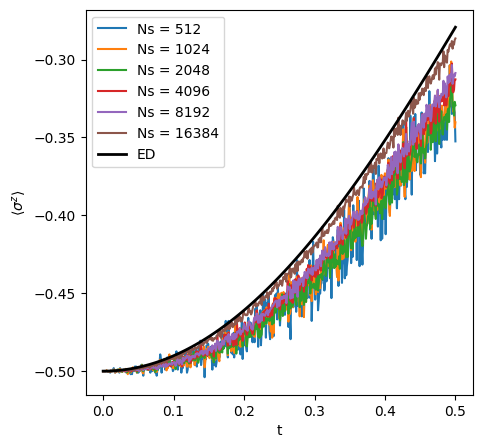

In [ ]:
fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
exact_exp_name = f"fixed_{2**14}"
save_path = f"./data/TFIM_EPS_{N}/{exact_exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
exact_val = logger.data["sigma_z"]["Mean"]
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["sigma_z"]["Mean"], label = f"Ns = {n_samples}", zorder=-1)
    ax_z.set_xlabel("t")
    ax_z.set_ylabel(r"$\langle\sigma^z \rangle$")

ax_z.plot(times_exact, np.real(magnetizations_exact), 'k-', linewidth=2, label='ED')
ax_z.legend()


Restored: True


/tmp/ipykernel_544605/3580412476.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snr.legend(loc="best")
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)
/tmp/ipykernel_544605/3580412476.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snrF.legend(loc="best")


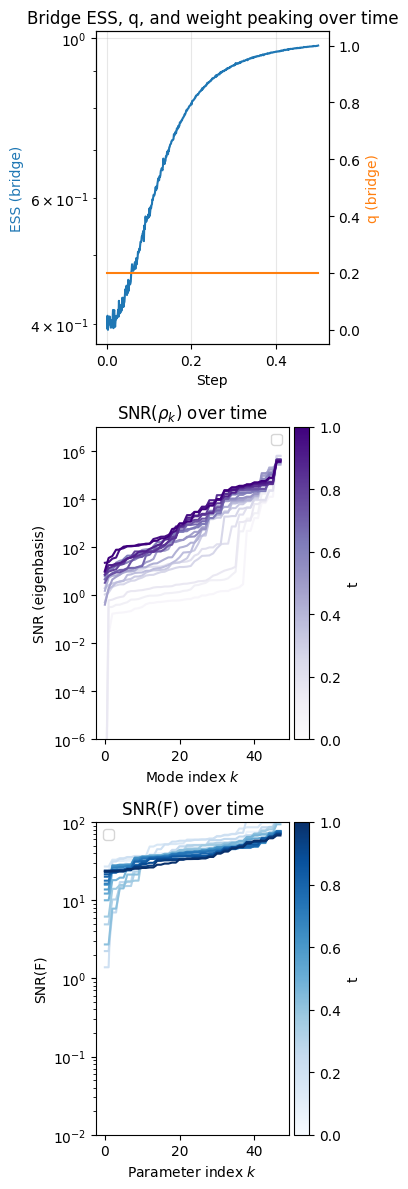

In [ ]:
n_samples_tvmc = 2**12
fig, (ax_essq,ax_snr,ax_snrF) = plt.subplots(3, 1, figsize=(4, 12))
exp_name = f"bridge_{n_samples_tvmc}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())

x_vals = logger.data["t"]["values"]
ess_vals = logger.data["ess_bridge"]["values"]
q_vals = logger.data["q_bridge"]["values"]
if ess_vals and q_vals:

    ax_right = ax_essq.twinx()
    (line1,) = ax_essq.plot(
        x_vals, ess_vals, color="tab:blue", label="ESS (bridge)"
    )
    # Also plot max_weight_over_mean on left axis
    (line2,) = ax_right.plot(
        x_vals, q_vals, color="tab:orange", label="q (bridge)"
    )

    ax_essq.set_xlabel("Step")
    ax_essq.set_ylabel("ESS (bridge)", color="tab:blue")
    ax_right.set_ylabel("q (bridge)", color="tab:orange")
    ax_essq.set_yscale('log')
    ax_right.set_ylim(-0.05, 1.05)
    ax_essq.grid(True, alpha=0.3)
    ax_essq.set_title("Bridge ESS, q, and weight peaking over time")

    lines = [line1, line2]
    labels = [l.get_label() for l in lines]

# Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
snr_len = len(logger.data.get("snr", {}).get("values", []))
cmap_snr = plt.get_cmap("Purples")
# Normalize step index to [0,1] for colorbar
norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
for i in range(snr_len):
    snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
    frac = 0.0 if snr_len <= 1 else i / (snr_len - 1)
    snr_data = np.nan_to_num(snr_data, 0.)
    ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
# if len(snr_min_series) > 0:
#     ax_snr.axhline(np.array(snr_min_series)[-1], color="gray", linestyle=":", label="min")
ax_snr.set_xlabel(r"Mode index $k$")
ax_snr.set_ylabel("SNR (eigenbasis)")
ax_snr.set_title(rf"SNR($\rho_k$) over time")
ax_snr.set_yscale("log")
ax_snr.set_ylim([1e-6, 1e7])
ax_snr.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
sm_snr.set_array([])
fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

# Top-middle: SNR(F) sorted curves with log y; add median and min lines
snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
cmap_snrF = plt.get_cmap("Blues")
for i in range(snrF_len):
    snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
    snr_F_data = np.nan_to_num(snr_F_data, 0.)
    frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
    ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
# if len(snrF_min_series) > 0:
#     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
ax_snrF.set_xlabel(r"Parameter index $k$")
ax_snrF.set_ylabel("SNR(F)")
ax_snrF.set_title(rf"SNR(F) over time")
ax_snrF.set_yscale("log")
ax_snrF.set_ylim([1e-2, 1e2])
ax_snrF.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")
plt.tight_layout()



Restored: True


/tmp/ipykernel_544605/3949401377.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_snrF.legend(loc="best")


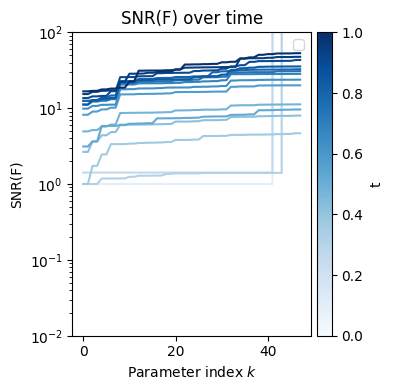

In [ ]:
n_samples_tvmc = 2**12
fig, ax_snrF = plt.subplots(1, 1, figsize=(4, 4))
exp_name = f"fixed_{n_samples_tvmc}"
save_path = f"./data/TFIM_EPS_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())

# Top-middle: SNR(F) sorted curves with log y; add median and min lines
snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
cmap_snrF = plt.get_cmap("Blues")
for i in range(snrF_len):
    snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
    snr_F_data = np.nan_to_num(snr_F_data, 0.)
    frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
    ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
# if len(snrF_min_series) > 0:
ax_snrF.set_xlabel(r"Parameter index $k$")
ax_snrF.set_ylabel("SNR(F)")
ax_snrF.set_title(rf"SNR(F) over time")
ax_snrF.set_yscale("log")
ax_snrF.set_ylim([1e-2, 1e2])
ax_snrF.legend(loc="best")
# Add colorbar for normalized step [0,1]
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
fig.colorbar(sm_snrF, ax=ax_snrF, pad=0.02, label="t")
plt.tight_layout()